# Example: composition validations

We want to be able to evaluate both an atlas and the resulting circuit on how well the recreate neuron density statistics for different cells.

parameterized validations, including the corresponding experimental data, can be imported from analysis_neuro.analyses

In [2]:
from analysis_neuro import analyses
import pandas as pd

bluebrain_models contains objects which implement measurements like cell_density, cell_count, etc.
The plan is to gradually increase the measurements available and the possible parameters of these measurements as we need them.
So for now it's only cell density, cell count, and region volume which are supported, and only for region and layer parameters, but new measurements can be added.

It will be a priority to make new methods and parameters easy to add, so that we can do it on the fly without costing too much time.

In [3]:
from bluebrain_models import BBPCircuit, BBPAtlas

In [4]:
atlas2019 = BBPAtlas("/gpfs/bbp.cscs.ch/project/proj68/entities/dev/atlas/ccf_2017-25um/20190208/", label='atlas2019')
atlas2021 = BBPAtlas("/gpfs/bbp.cscs.ch/project/proj82/entities/atlas/ThalNCX/20210531/", label='atlas2021')
atlas2022 = BBPAtlas("/gpfs/bbp.cscs.ch/project/proj148/scratch/circuits/20221114/.atlas", label='atlas2022')
VISp2022 = BBPCircuit("/gpfs/bbp.cscs.ch/project/proj148/scratch/V1/sonata/circuit_config.json", label='circuit')


In [7]:
#VISp2022.cell_count(pd.DataFrame())
from tqdm import tqdm
import yaml
class BBPAtlasMeTypes(BBPAtlas):
    def _densities(self, parameters):
        comp = yaml.load(open(self._path / 'composition.yaml', 'r'), Loader=yaml.SafeLoader)
        metd = [el['density'][1:][:-1] for el in comp['neurons']]
        total = sum(self._atlas.load_data(met).raw for met in tqdm(metd))
        return [total for _ in range(parameters.shape[0])]


 13%|████████████████████▊                                                                                                                                               | 38/300 [01:23<09:24,  2.15s/it]


 26%|██████████████████████████████████████████                                                                                                                          | 77/300 [02:47<08:00,  2.15s/it]


 39%|███████████████████████████████████████████████████████████████                                                                                                    | 116/300 [04:11<06:37,  2.16s/it]


 52%|████████████████████████████████████████████████████████████████████████████████████▏                                                                              | 155/300 [05:35<05:12,  2.16s/it]


 65%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                                         | 194/300 [06:59<03:48,  2.16s/it]


 78%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                    | 233/300 [08:24<02:24,  2.15s/it]


 91%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊               | 272/300 [09:48<01:00,  2.17s/it]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [10:48<00:00,  2.16s/it]


{'Introduction': '\n    We evaluate the similarity of the total neuron density in the primary\n    visual cortex of the model to in-vivo values by comparing to the\n    mean density observed in @schuz_density_1989.\n    Because Schuz does not report the individual densities for the three\n    mice used, we cannot perform a statistical test.\n    So instead we use a mean squared error to quantify the mismatch.\n    We cannot render a verdict on the result, only assign a score.\n    ',
 'measurements':   layer  cell density ($cells/mm^3$) region     dataset            citation  \
 0   L23                140000.000000   VISp  Schuz 1989  schuz_density_1989   
 1    L4                200000.000000   VISp  Schuz 1989  schuz_density_1989   
 2    L5                 80000.000000   VISp  Schuz 1989  schuz_density_1989   
 3    L6                150000.000000   VISp  Schuz 1989  schuz_density_1989   
 0   L23                 91424.794826   VISp       atlas                 NaN   
 1    L4       

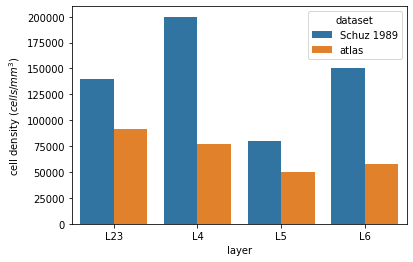

In [8]:
analyses.schuz_density_1989(BBPAtlasMeTypes("/gpfs/bbp.cscs.ch/project/proj148/scratch/circuits/20221114/.atlas"))

{'Introduction': '\n    We evaluate the similarity of the total neuron density in the primary\n    visual cortex of the model to in-vivo values by comparing to the\n    mean density observed in @schuz_density_1989.\n    Because Schuz does not report the individual densities for the three\n    mice used, we cannot perform a statistical test.\n    So instead we use a mean squared error to quantify the mismatch.\n    We cannot render a verdict on the result, only assign a score.\n    ',
 'measurements':   layer  cell density ($cells/mm^3$) region     dataset            citation  \
 0   L23                140000.000000   VISp  Schuz 1989  schuz_density_1989   
 1    L4                200000.000000   VISp  Schuz 1989  schuz_density_1989   
 2    L5                 80000.000000   VISp  Schuz 1989  schuz_density_1989   
 3    L6                150000.000000   VISp  Schuz 1989  schuz_density_1989   
 0   L23                 90089.592350   VISp     circuit                 NaN   
 1    L4       

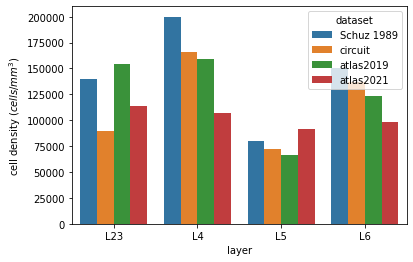

In [9]:
schuz_result = analyses.schuz_density_1989(VISp2022, atlas2019, atlas2021)
schuz_result

This validation did actually reveal a problem with the VISp circuit and the dedicated atlas, the density is too low overall, especially so in L23, even though they were constrained using this data.

I've identified the issue and am working on it for the next VISp circuit.


 13%|████████████████████▊                                                                                                                                               | 38/300 [01:22<09:25,  2.16s/it]


 26%|██████████████████████████████████████████                                                                                                                          | 77/300 [02:47<08:01,  2.16s/it]


 39%|███████████████████████████████████████████████████████████████                                                                                                    | 116/300 [04:11<06:38,  2.17s/it]


 52%|████████████████████████████████████████████████████████████████████████████████████▏                                                                              | 155/300 [05:36<05:13,  2.16s/it]


 65%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                                         | 194/300 [07:00<03:49,  2.16s/it]


 78%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                    | 233/300 [08:24<02:24,  2.16s/it]


 91%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊               | 272/300 [09:49<01:00,  2.17s/it]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [10:49<00:00,  2.17s/it]


,species,region,whatever metadata,sample size,std cell density ($cells/mm^3$),layer
0,mouse,SSp-ll,blah blah blah,6,1910,L1
1,mouse,SSp-ll,blah blah blah,6,8136,L2
2,mouse,SSp-ll,blah blah blah,6,6822,L3
3,mouse,SSp-ll,blah blah blah,6,3778,L4
4,mouse,SSp-ll,blah blah blah,6,4138,L5
5,mouse,SSp-ll,blah blah blah,6,4060,L6


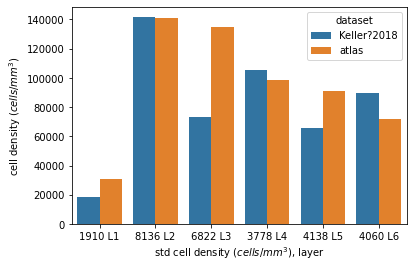

In [10]:
keller_result = analyses.keller_density_2018(BBPAtlasMeTypes("/gpfs/bbp.cscs.ch/project/proj148/scratch/circuits/20221114/.atlas"))
analyses.keller_density_2018.parameters

In [ ]:
print(analyses.schuz_density_1989.parameters)

In [ ]:
thal2022 = BBPCircuit("/gpfs/bbp.cscs.ch/project/proj82/circuits/Thalamus/20220125/sonata/circuit_config.json", label='Thal2022')

In [ ]:
analyses.thalamic_nuclei_cell_counts(atlas2021, thal2022)

So the above plot is a bit wonky - it's reserving values for both datasets even when they don't provide a value.
Maybe it should be standard practice to split into two validations - as different datasets will have subtly different methods that may need to be handled differently.